# Q1: Detection statistic with distance-marginalised CW

CW pulsar-term distances are analytically marginalised (Gaussian prior); the pulsar term is evaluated at the prior mean distance and attenuated by the coherence factor $\kappa = \exp[-	frac12 (\omega (1-\cos\mu) \sigma_d \; kpc/c)^2]$. Detection statistic now uses log posterior (loglike with distance prior folded in) and is sensitive to distance prior tiers.

In [ ]:

from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from scipy import optimize

# Ensure local modules are importable
cwd = Path.cwd()
if str(cwd) not in sys.path:
    sys.path.insert(0, str(cwd))

from sim import (
    Q1Config,
    DistanceTier,
    draw_cw_population,
    load_enterprise_pulsars,
    load_discovery_pulsars,
    build_enterprise_pta,
    build_discovery_loglike_marginalized,
    draw_noise_params,
    inject_cw_params,
    simulate_enterprise_residuals,
    set_toaerrs,
    make_rng,
)

from optimization_helpers import (
    load_discovery_pulsars_cached,
    build_base_params_with_sigma,
    update_sigma_params,
    compute_detection_statistic_optimized,
    LikelihoodCache,
)

/home/mattm/miniforge3/envs/discotech/lib/python3.12/site-packages/enterprise/signals/utils.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import Requirement, resource_filename


In [ ]:
# Configuration defaults
scenario = "B"          # 'A' (WN), 'B' (WN+RN), 'C' (WN+RN+GWB)
n_pulsars = 30
seed = 123
snrs = [5, 10, 20]
tiers = [
    "real",
    "tier1",
    "tier2_k=1.6",
    "tier2_k=2",
    "tier2_k=3",
    "tier2_k=5",
    "tier3",
]

# Grids for profiling CW parameters
# Increased resolution for clearer contour structure
n_cos = 120    # Increased from 60 (2x finer)
n_phi = 120    # Increased from 60 (2x finer)
n_amp = 8      # Reduced from 15 (still sufficient for amplitude max)
amp_span = 1.5   # search log10_h in [inj - amp_span, inj + amp_span]
null_amp = -30.0 # effectively no signal

cfg = Q1Config(
    n_pulsars=n_pulsars,
    scenario=scenario,
    seed=seed,
    distance_tier=DistanceTier("real", 1.0),
    include_pterm=True,
    same_freq=False,
    same_loc=False,
)

log10_fgw_override = -10.5

log10_fgw_override_toy = -10.5  # toy override; set None to use default

# Optional overrides for tests
sigma_scale_override = None # scale sigmas to pc-level for diagnostics
use_small_pta = False

### Note on distance handling and detection statistic

Distances are analytically marginalised in the CW delay. The pulsar term is evaluated at the prior mean distance and suppressed by the coherence factor derived from the distance uncertainty. There are no distance parameters in the fit. The detection statistic uses the log posterior (loglike with the marginalised distance prior built in):

$$D = 2 (\log \mathcal{P}_{	ext{signal,max}} - \log \mathcal{P}_{	ext{null,max}}),$$

where $\log \mathcal{P}$ is the marginalised log likelihood for the chosen distance tier.

In [3]:
# Helper utilities

def apply_distance_prior_tier(pulsar_names, true_dists, true_sigs, tier: str, k_loose: float = 5.0):
    """Return mapping pulsar -> (mean, sigma) according to tier."""
    tier = tier.lower()
    priors = {}
    tighten = None
    if tier.startswith("tier2_k="):
        try:
            tighten = float(tier.split("=")[1])
        except Exception:
            tighten = 2.0
    for name in pulsar_names:
        mu = float(true_dists[name])
        sigma = float(true_sigs[name])
        if sigma <= 0 or not np.isfinite(sigma):
            sigma = 0.5
        if tier == "real":
            s = sigma
        elif tier == "tier1":
            s = sigma * k_loose
        elif tier == "tier3":
            s = 1e-6  # effectively exact
        elif tighten is not None:
            s = sigma / tighten
        else:
            s = sigma
        priors[name] = (mu, s)
    return priors


def find_cw_param_names(param_keys):
    def pick(substr):
        for k in param_keys:
            if substr in k:
                return k
        raise ValueError(f"Missing parameter with token {substr}")
    return {
        "cos": pick("cos_gwtheta"),
        "phi": pick("gwphi"),
        "amp": pick("log10_h"),
    }


def build_base_params(param_keys, inj_params, cw_draws):
    params = {k: inj_params.get(k, 0.0) for k in param_keys}
    for draw in cw_draws:
        suffix = draw.get("suffix", "")
        for field in ["cos_gwtheta", "gwphi", "cos_inc", "log10_mc", "log10_fgw", "log10_h", "phase0", "psi"]:
            name = f"cw_{field}{suffix}"
            if name in params:
                params[name] = draw[field]
    return params


def compute_detection_statistic(logl, param_keys, base_params, cw_names, cos_grid, phi_grid, amp_grid, null_amp):
    """Compute D using JAX vmaps/JIT; fallback to NumPy loops if JAX fails."""
    try:
        cos_grid_j = jnp.array(cos_grid)
        phi_grid_j = jnp.array(phi_grid)
        amp_grid_j = jnp.array(amp_grid)
        base_vec = jnp.array([base_params[k] for k in param_keys])
        idx_cos = param_keys.index(cw_names["cos"])
        idx_phi = param_keys.index(cw_names["phi"])
        idx_amp = param_keys.index(cw_names["amp"])

        @jax.jit
        def logl_from_x(x):
            params = {k: x[i] for i, k in enumerate(param_keys)}
            return logl(params)

        def grid_eval():
            def eval_cos(c):
                def eval_phi(p):
                    vals = jax.vmap(lambda a: logl_from_x(base_vec.at[idx_cos].set(c).at[idx_phi].set(p).at[idx_amp].set(a)))(amp_grid_j)
                    return vals.max()
                return jax.vmap(eval_phi)(phi_grid_j)
            return jax.vmap(eval_cos)(cos_grid_j)

        logL_grid = grid_eval()
        logL_max = float(logL_grid.max())
        logL_grid_np = np.array(logL_grid)

        x_null = base_vec.at[idx_amp].set(null_amp)
        logL_null = float(logl_from_x(x_null))
        d_stat = 2 * (logL_max - logL_null)
        return d_stat, logL_null, logL_max, logL_grid_np
    except Exception:
        logL_grid = np.zeros((len(cos_grid), len(phi_grid)))
        for i, cosv in enumerate(cos_grid):
            for j, phiv in enumerate(phi_grid):
                best = -np.inf
                for ampv in amp_grid:
                    params = dict(base_params)
                    params[cw_names["cos"]] = float(cosv)
                    params[cw_names["phi"]] = float(phiv)
                    params[cw_names["amp"]] = float(ampv)
                    lp = float(logl(params))
                    if lp > best:
                        best = lp
                logL_grid[i, j] = best
        logL_max = float(logL_grid.max())
        params_null = dict(base_params)
        params_null[cw_names["amp"]] = null_amp
        logL_null = float(logl(params_null))
        d_stat = 2 * (logL_max - logL_null)
        return d_stat, logL_null, logL_max, logL_grid


def compute_hpd_area(cos_grid, phi_grid, posterior, frac=0.9):
    flat = posterior.ravel()
    order = np.argsort(flat)[::-1]
    csum = np.cumsum(flat[order])
    mask = csum <= frac
    if not mask.any():
        mask[0] = True
    selected = np.zeros_like(flat, dtype=bool)
    selected[order[mask]] = True
    selected = selected.reshape(posterior.shape)
    dcos = np.diff(cos_grid).mean()
    dphi = np.diff(phi_grid).mean()
    pixel_area = dcos * dphi
    area_sr = selected.sum() * pixel_area
    area_deg2 = area_sr * (180 / np.pi) ** 2
    return area_sr, area_deg2, selected


def compute_sky_localisation(cos_grid, phi_grid, logL_grid, inj_cos, inj_phi, frac=0.9):
    logL_max = logL_grid.max()
    posterior = np.exp(logL_grid - logL_max)
    posterior /= posterior.sum()
    area_sr, area_deg2, mask = compute_hpd_area(cos_grid, phi_grid, posterior, frac=frac)
    inj_phi_wrap = (inj_phi + 2 * np.pi) % (2 * np.pi)
    phi_wrap = (phi_grid + 2 * np.pi) % (2 * np.pi)
    i_cos = int(np.argmin(np.abs(cos_grid - inj_cos)))
    i_phi = int(np.argmin(np.abs(phi_wrap - inj_phi_wrap)))
    inside = bool(mask[i_cos, i_phi])
    return area_sr, area_deg2, inside, posterior, mask


In [4]:
# Data simulation and likelihood construction

def simulate_data(snr, cfg):
    rng = make_rng(cfg.seed if cfg.seed is not None else 0)
    cw_draws = draw_cw_population(cfg, rng)
    # Global override for main run
    if "log10_fgw_override" in globals() and log10_fgw_override is not None:
        cw_draws[0]["log10_fgw"] = log10_fgw_override
    # Toy-specific override (only used in toy cells)
    if "log10_fgw_override_toy" in globals() and log10_fgw_override_toy is not None:
        cw_draws[0]["log10_fgw"] = log10_fgw_override_toy
    if log10_fgw_override is not None:
        cw_draws[0]["log10_fgw"] = log10_fgw_override
    cw_draws[0]["log10_h"] = cw_draws[0]["log10_h"] + np.log10(max(snr, 1) / 10.0)

    e_psrs = load_enterprise_pulsars(cfg)
    if use_small_pta:
        e_psrs = e_psrs[:5]  # small subset for diagnostics
    set_toaerrs(e_psrs, sigma=1e-6)
    true_dists = {p.name: float(p.pdist[0]) for p in e_psrs}
    true_sigs = {p.name: float(p.pdist[1]) if len(np.atleast_1d(p.pdist))>1 else 0.0 for p in e_psrs}
    if sigma_scale_override is not None:
        true_sigs = {k: v * sigma_scale_override for k, v in true_sigs.items()}
    # fallback if sigma missing/zero
    for k,v in list(true_sigs.items()):
        if v <= 0 or not np.isfinite(v):
            true_sigs[k] = 0.5

    pta, ring_vecs = build_enterprise_pta(e_psrs, cfg, cw_draws)
    pta.set_default_params({})
    noise_params = draw_noise_params(pta, cfg, rng, psrs=e_psrs)
    inj_params = inject_cw_params(noise_params, cw_draws, cfg)
    sim_resids = simulate_enterprise_residuals(pta, inj_params, sparse_cholesky=True)
    name_to_resid = {getattr(p, "name", p): y for p, y in zip(pta.pulsars, sim_resids)}

    d_psrs = load_discovery_pulsars(cfg)
    if use_small_pta:
        d_psrs = [psr for psr in d_psrs if psr.name in name_to_resid]
        ring_vecs_out = ring_vecs[: len(d_psrs)]
    else:
        ring_vecs_out = ring_vecs
    residual_map = {psr.name: name_to_resid[psr.name] for psr in d_psrs}

    return {
        "cw_draws": cw_draws,
        "true_dists": true_dists,
        "true_sigs": true_sigs,
        "residual_map": residual_map,
        "ring_vecs": ring_vecs_out,
        "inj_params": inj_params,
    }


In [ ]:
# Optimized main loop with likelihood caching
results = []
posterior_cache = {}
likelihood_cache = LikelihoodCache()

for snr in snrs:
    try:
        # Build likelihood ONCE per SNR (cached)
        def build_likelihood_fn(d_psrs, data, dist_priors):
            from sim import build_discovery_loglike_marginalized
            return build_discovery_loglike_marginalized(
                d_psrs,
                data["cw_draws"],
                cfg,
                dist_priors,
                ring_vecs=data["ring_vecs"][:len(d_psrs)] if use_small_pta else data["ring_vecs"],
                residual_map=data["residual_map"],
                include_cw=True,
            )

        cached = likelihood_cache.build_or_get(snr, cfg, simulate_data, build_likelihood_fn)
        logl = cached["logl"]
        param_keys = cached["param_keys"]
        data = cached["data"]

    except Exception as exc:
        print(f"Failed to build likelihood for snr={snr}: {exc}")
        continue

    cos_grid = np.linspace(-1, 1, n_cos)
    phi_grid = np.linspace(0, 2 * np.pi, n_phi)

    for tier in tiers:
        try:
            # Update distance priors for this tier
            dist_priors = apply_distance_prior_tier(
                list(data["true_dists"].keys()),
                data["true_dists"],
                data["true_sigs"],
                tier
            )

            # Build parameters with updated sigma values
            # This is much faster than rebuilding the likelihood!
            base_params = build_base_params_with_sigma(
                param_keys,
                data["inj_params"],
                data["cw_draws"],
                dist_priors
            )

            cw_names = find_cw_param_names(param_keys)
            amp_grid = np.linspace(
                base_params[cw_names["amp"]] - amp_span,
                base_params[cw_names["amp"]] + amp_span,
                n_amp
            )

            # Use optimized detection statistic computation
            d_stat, logL_null, logL_max, logL_grid = compute_detection_statistic_optimized(
                logl,
                param_keys,
                base_params,
                cw_names,
                cos_grid,
                phi_grid,
                amp_grid,
                null_amp=null_amp,
            )

            area_sr, area_deg2, inside, posterior, mask = compute_sky_localisation(
                cos_grid, phi_grid, logL_grid,
                data["cw_draws"][0]["cos_gwtheta"],
                data["cw_draws"][0]["gwphi"],
                frac=0.9
            )

            key = (snr, tier)
            posterior_cache[key] = {
                "cos_grid": cos_grid,
                "phi_grid": phi_grid,
                "posterior": posterior,
                "mask": mask,
                "logL_grid": logL_grid,
            }

            results.append({
                "snr": snr,
                "tier": tier,
                "D_stat": d_stat,
                "logL_null": logL_null,
                "logL_max": logL_max,
                "area90_deg2": area_deg2,
                "inside90": inside,
            })

        except Exception as exc:
            print(f"Tier {tier} failed for snr={snr}: {exc}")
            import traceback
            traceback.print_exc()
            continue

print(f"Completed {len(results)} runs")
results

FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cann

W1204 14:14:57.255892 1253170 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W1204 14:14:57.257129 1252489 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.


KeyboardInterrupt: 

In [ ]:
from discovery import deterministic as det

def summarize_kappa(data, cfg, tiers):
    d_psrs = load_discovery_pulsars(cfg)
    psr_names = [psr.name for psr in d_psrs]
    gwtheta = np.arccos(data["cw_draws"][0]["cos_gwtheta"])
    gwphi = data["cw_draws"][0]["gwphi"]
    log10_fgw = data["cw_draws"][0]["log10_fgw"]
    w0 = np.pi * (10.0 ** log10_fgw)

    for tier in tiers:
        dist_priors = apply_distance_prior_tier(
            psr_names, data["true_dists"], data["true_sigs"], tier
        )
        ks = []
        kappas = []
        for psr in d_psrs:
            mu, sigma = dist_priors[psr.name]
            _, _, cos_mu = det.fpcmu_fast(psr.pos, gwtheta, gwphi)
            k_sigma = 2.0 * w0 * (1.0 - cos_mu) * (det.const.kpc / det.const.c) * sigma
            kappa = np.exp(-0.5 * k_sigma**2)
            ks.append(float(k_sigma))
            kappas.append(float(kappa))
        ks = np.array(ks)
        kappas = np.array(kappas)
        print(
            f"{tier:10s}: k_sigma median={np.median(ks):.3e}, "
            f"[min,max]=[{ks.min():.3e},{ks.max():.3e}], "
            f"kappa median={np.median(kappas):.5f}, "
            f"[min,max]=[{kappas.min():.5f},{kappas.max():.5f}]"
        )

data_diag = simulate_data(10, cfg)
summarize_kappa(data_diag, cfg, tiers)


FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cann

In [ ]:
# Plot detection statistic vs tier for each SNR
from collections import defaultdict

by_snr = defaultdict(list)
for row in results:
    by_snr[row["snr"]].append(row)

# Plot 1: Combined view (all SNRs together)
fig, ax = plt.subplots(figsize=(10, 5))
x_positions = np.arange(len(tiers))
width = 0.25
for idx, snr in enumerate(snrs):
    rows = sorted(by_snr[snr], key=lambda r: tiers.index(r["tier"]))
    vals = [r["D_stat"] for r in rows]
    ax.bar(x_positions + idx * width, vals, width=width, label=f"SNR {snr}")
ax.set_xticks(x_positions + width * (len(snrs) - 1) / 2)
ax.set_xticklabels(tiers, rotation=45, ha="right")
ax.set_ylabel("Detection statistic D")
ax.set_yscale('log')
ax.legend()
ax.set_title("Detection statistic vs distance prior tier (marginalised CW)")
plt.tight_layout()
plt.show()

# Plot 2: Individual plots for each SNR showing tier comparisons (log scale)
fig, axes = plt.subplots(1, len(snrs), figsize=(5 * len(snrs), 4), sharey=False)
if len(snrs) == 1:
    axes = [axes]

for idx, snr in enumerate(snrs):
    ax = axes[idx]
    rows = sorted(by_snr[snr], key=lambda r: tiers.index(r["tier"]))
    vals = [r["D_stat"] for r in rows]
    
    # Bar plot for this SNR
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(tiers)))
    bars = ax.bar(range(len(tiers)), vals, color=colors, edgecolor='black', linewidth=0.5)
    
    ax.set_xticks(range(len(tiers)))
    ax.set_xticklabels(tiers, rotation=45, ha="right")
    ax.set_xlabel("Distance prior tier")
    ax.set_ylabel("Detection statistic D")
    ax.set_title(f"SNR = {snr}")
    ax.set_yscale('log')
    ax.grid(axis='y', alpha=0.3, which='both')

plt.suptitle("Detection Statistic by Distance Prior Tier (per SNR, log scale)", y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 3: Stacked line plots showing trend across tiers (one subplot per SNR, log scale)
fig, axes = plt.subplots(len(snrs), 1, figsize=(10, 4 * len(snrs)), sharex=True)
if len(snrs) == 1:
    axes = [axes]

for idx, snr in enumerate(snrs):
    ax = axes[idx]
    rows = sorted(by_snr[snr], key=lambda r: tiers.index(r["tier"]))
    vals = [r["D_stat"] for r in rows]
    
    ax.plot(range(len(tiers)), vals, marker='o', linewidth=2, markersize=8, 
            color=f'C{idx}', label=f"SNR {snr}")
    
    ax.set_ylabel("Detection statistic D")
    ax.set_yscale('log')
    ax.legend(loc='best')
    ax.grid(alpha=0.3, which='both')

# Only set x-axis labels on bottom plot
axes[-1].set_xticks(range(len(tiers)))
axes[-1].set_xticklabels(tiers, rotation=45, ha="right")
axes[-1].set_xlabel("Distance prior tier")

plt.suptitle("Detection Statistic Trends Across Distance Prior Tiers (log scale)", y=0.995, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 4: Stacked line plots WITHOUT tier1 (one subplot per SNR, log scale)
tiers_no_tier1 = [t for t in tiers if t != "tier1"]
tier_indices_no_tier1 = [i for i, t in enumerate(tiers) if t != "tier1"]

fig, axes = plt.subplots(len(snrs), 1, figsize=(10, 4 * len(snrs)), sharex=True)
if len(snrs) == 1:
    axes = [axes]

for idx, snr in enumerate(snrs):
    ax = axes[idx]
    rows = sorted(by_snr[snr], key=lambda r: tiers.index(r["tier"]))
    # Filter out tier1
    rows_filtered = [r for r in rows if r["tier"] != "tier1"]
    vals = [r["D_stat"] for r in rows_filtered]
    
    ax.plot(range(len(vals)), vals, marker='o', linewidth=2, markersize=8, 
            color=f'C{idx}', label=f"SNR {snr}")
    
    ax.set_ylabel("Detection statistic D")
    ax.set_yscale('log')
    ax.legend(loc='best')
    ax.grid(alpha=0.3, which='both')

# Only set x-axis labels on bottom plot
axes[-1].set_xticks(range(len(tiers_no_tier1)))
axes[-1].set_xticklabels(tiers_no_tier1, rotation=45, ha="right")
axes[-1].set_xlabel("Distance prior tier")

plt.suptitle("Detection Statistic Trends Across Distance Prior Tiers (log scale, excluding tier1)", y=0.995, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 5: Individual plots for each SNR WITHOUT tier1 (log scale)
fig, axes = plt.subplots(1, len(snrs), figsize=(5 * len(snrs), 4), sharey=False)
if len(snrs) == 1:
    axes = [axes]

for idx, snr in enumerate(snrs):
    ax = axes[idx]
    rows = sorted(by_snr[snr], key=lambda r: tiers.index(r["tier"]))
    # Filter out tier1
    rows_filtered = [r for r in rows if r["tier"] != "tier1"]
    vals = [r["D_stat"] for r in rows_filtered]
    
    # Bar plot for this SNR
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(vals)))
    bars = ax.bar(range(len(vals)), vals, color=colors, edgecolor='black', linewidth=0.5)
    
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(tiers_no_tier1, rotation=45, ha="right")
    ax.set_xlabel("Distance prior tier")
    ax.set_ylabel("Detection statistic D")
    ax.set_title(f"SNR = {snr}")
    ax.set_yscale('log')
    ax.grid(axis='y', alpha=0.3, which='both')

plt.suptitle("Detection Statistic by Distance Prior Tier (per SNR, log scale, excluding tier1)", y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

SNRs:   0%|          | 0/3 [00:00<?, ?it/s]

Realisations (SNR=5):   0%|          | 0/1 [00:00<?, ?it/s]

FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cann

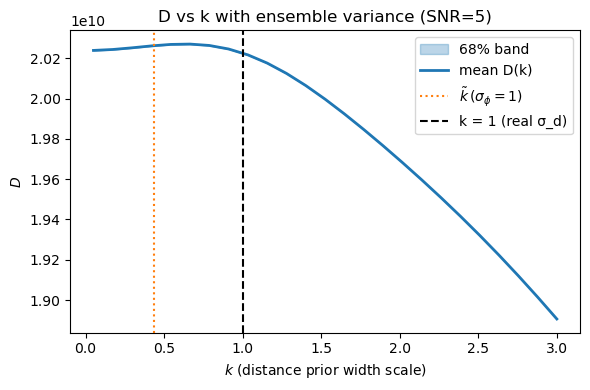

Realisations (SNR=10):   0%|          | 0/1 [00:00<?, ?it/s]

FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cann

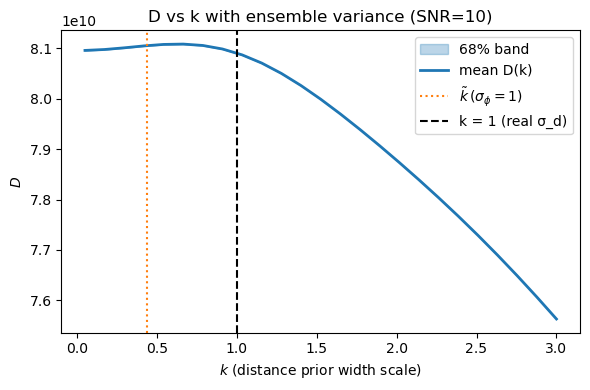

Realisations (SNR=20):   0%|          | 0/1 [00:00<?, ?it/s]

FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cann

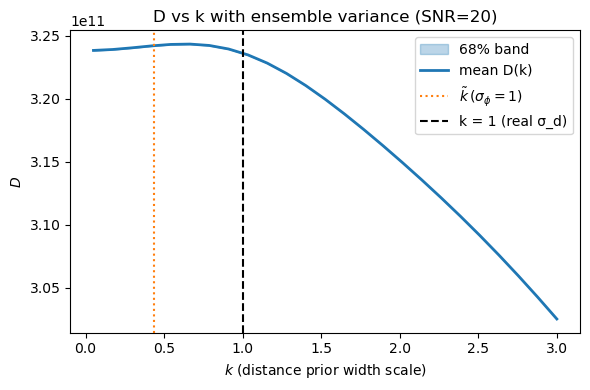

In [ ]:
from tqdm.auto import tqdm
from pathlib import Path
from discovery import deterministic as det

# Settings
k_min, k_max, n_k = 0.05, 3.0, 25
k_grid = np.linspace(k_min, k_max, n_k)
n_real = 1

# Coarse grid for speed
n_cos_fast = 40
n_phi_fast = 40
n_amp_fast = 11
cos_grid = np.linspace(-1, 1, n_cos_fast)
phi_grid = np.linspace(0, 2 * np.pi, n_phi_fast)

ensemble_D = {}
k_likelihood_cache = LikelihoodCache()  # Separate cache for k-sweep

for snr in tqdm(snrs, desc="SNRs"):
    D_samples = []

    for r in tqdm(range(n_real), desc=f"Realisations (SNR={snr})", leave=False):
        data = simulate_data(snr, cfg)

        # Build likelihood ONCE per realization
        def build_k_likelihood_fn(d_psrs, data, dist_priors):
            from sim import build_discovery_loglike_marginalized
            return build_discovery_loglike_marginalized(
                d_psrs, data["cw_draws"], cfg, dist_priors,
                ring_vecs=data["ring_vecs"], residual_map=data["residual_map"],
                include_cw=True,
            )

        # Use a unique cache key per realization
        cache_key = (snr, r)
        cached = k_likelihood_cache.build_or_get(cache_key, cfg, lambda s, c: data, build_k_likelihood_fn)
        logl = cached["logl"]
        param_keys = cached["param_keys"]

        D_vals = []
        for k_scale in k_grid:
            # Update distance priors for this k-scale
            dist_priors_k = {
                name: (data["true_dists"][name], k_scale * data["true_sigs"][name])
                for name in data["true_dists"].keys()
            }

            # Update sigma parameters (no likelihood rebuild!)
            base_params_k = build_base_params_with_sigma(
                param_keys,
                data["inj_params"],
                data["cw_draws"],
                dist_priors_k
            )

            cw_names_k = find_cw_param_names(param_keys)
            amp_center = base_params_k[cw_names_k["amp"]]
            amp_grid = np.linspace(amp_center - amp_span, amp_center + amp_span, n_amp_fast)

            D_k, logL_null_k, logL_max_k, _ = compute_detection_statistic_optimized(
                logl, param_keys, base_params_k, cw_names_k,
                cos_grid, phi_grid, amp_grid, null_amp=null_amp,
            )
            D_vals.append(D_k)

        D_samples.append(D_vals)

    D_samples = np.array(D_samples)
    ensemble_D[snr] = {"k": k_grid.copy(), "D_samples": D_samples}

    # Summary: mean and 16–84% band
    D_mean = D_samples.mean(axis=0)
    D_p16 = np.percentile(D_samples, 16, axis=0)
    D_p84 = np.percentile(D_samples, 84, axis=0)

    # Compute a representative k where median σ_phase = 1 for this SNR
    data_diag = simulate_data(snr, cfg)
    d_psrs_diag = load_discovery_pulsars(cfg)
    psr_names_diag = [psr.name for psr in d_psrs_diag]

    # GW direction and frequency
    gwtheta_diag = np.arccos(data_diag["cw_draws"][0]["cos_gwtheta"])
    gwphi_diag = data_diag["cw_draws"][0]["gwphi"]
    log10_fgw_diag = data_diag["cw_draws"][0]["log10_fgw"]
    w0_diag = np.pi * (10.0 ** log10_fgw_diag)

    # Distance priors for the "real" tier (no scaling)
    dist_priors_diag = apply_distance_prior_tier(
        psr_names_diag,
        data_diag["true_dists"],
        data_diag["true_sigs"],
        tier="real",
    )

    # k_sigma0 = σ_phase at k = 1: 2 * w0 * (1 - cos μ) * (kpc/c) * σ_d
    k_sigmas = []
    for psr in d_psrs_diag:
        _, sigma_d = dist_priors_diag[psr.name]
        _, _, cos_mu = det.fpcmu_fast(psr.pos, gwtheta_diag, gwphi_diag)
        k_sigma0 = 2.0 * w0_diag * (1.0 - cos_mu) * (det.const.kpc / det.const.c) * sigma_d
        k_sigmas.append(float(k_sigma0))

    k_sigmas = np.array(k_sigmas)
    k_sigmas = k_sigmas[np.isfinite(k_sigmas) & (k_sigmas > 0)]

    # σ_phase(k) = k * k_sigma0, so median σ_phase = 1 at:
    k_phase = 1.0 / np.median(k_sigmas)


    fig = plt.figure(figsize=(6, 4))
    plt.fill_between(k_grid, D_p16, D_p84, color="C0", alpha=0.3, label="68% band")
    plt.plot(k_grid, D_mean, color="C0", lw=2, label="mean D(k)")
    plt.axvline(k_phase, color="C1", linestyle=":", label=r"$\tilde{k}\,(\sigma_\phi=1)$")
    plt.axvline(1.0, color="k", linestyle="--", label="k = 1 (real σ_d)")
    plt.xlabel(r"$k$ (distance prior width scale)")
    plt.ylabel(r"$D$")
    plt.title(f"D vs k with ensemble variance (SNR={snr})")
    plt.legend()
    plt.tight_layout()

    outdir = "/home/mattm/projects/HSYMT/MAIN_PROJECT_QUESTIONS/Q1/"

    # Save figure next to the notebook
    fname = outdir + f"/D_vs_k_snr{snr}.png"
    fig.savefig(fname, dpi=150)
    plt.show()


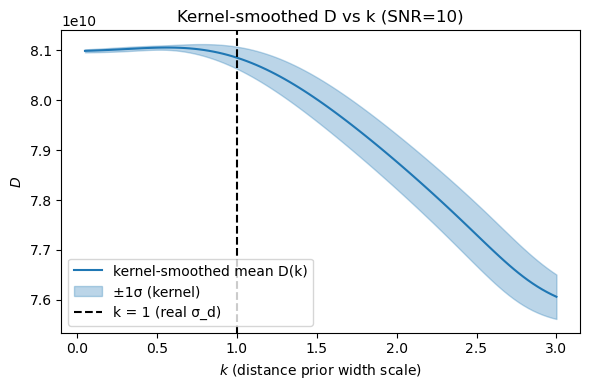

In [7]:
# After you have ensemble_D[snr] = {"k": k_grid, "D_samples": (n_real, n_k)}

def kernel_smooth_D_vs_k(k_samples, D_samples, k_eval, h=0.2):
    """
    k_samples: shape (N,)  flattened k values (all realisations and k_grid points)
    D_samples: shape (N,)  corresponding D values
    k_eval:    1D array of k values where you want smoothed estimates
    h:         kernel bandwidth in k
    """
    k_samples = np.asarray(k_samples)
    D_samples = np.asarray(D_samples)
    k_eval = np.asarray(k_eval)

    D_mean = np.zeros_like(k_eval)
    D_var = np.zeros_like(k_eval)

    for i, k0 in enumerate(k_eval):
        w = np.exp(-0.5 * ((k0 - k_samples) / h) ** 2)
        if w.sum() == 0:
            D_mean[i] = np.nan
            D_var[i] = np.nan
            continue
        w /= w.sum()
        m = np.sum(w * D_samples)
        v = np.sum(w * (D_samples - m) ** 2)
        D_mean[i] = m
        D_var[i] = v

    return D_mean, D_var

# Example usage for one SNR:
snr_example = snrs[1]  # e.g. SNR=10
data_snr = ensemble_D[snr_example]  # from the ensemble cell
k_grid = data_snr["k"]              # shape (n_k,)
D_samples = data_snr["D_samples"]   # shape (n_real, n_k)

# Flatten (k,D) pairs over all realisations and k-grid points
k_all = np.repeat(k_grid[None, :], D_samples.shape[0], axis=0).ravel()
D_all = D_samples.ravel()

# Choose a finer k grid to evaluate the smoothed curve
k_eval = np.linspace(k_grid.min(), k_grid.max(), 100)
D_mean, D_var = kernel_smooth_D_vs_k(k_all, D_all, k_eval, h=0.2)
D_std = np.sqrt(D_var)

plt.figure(figsize=(6, 4))
plt.plot(k_eval, D_mean, color="C0", label="kernel-smoothed mean D(k)")
plt.fill_between(k_eval, D_mean - D_std, D_mean + D_std,
                 color="C0", alpha=0.3, label="±1σ (kernel)")
plt.axvline(1.0, color="k", linestyle="--", label="k = 1 (real σ_d)")
plt.xlabel(r"$k$ (distance prior width scale)")
plt.ylabel(r"$D$")
plt.title(f"Kernel-smoothed D vs k (SNR={snr_example})")
plt.legend()
plt.tight_layout()
plt.show()


NameError: name 'by_snr' is not defined

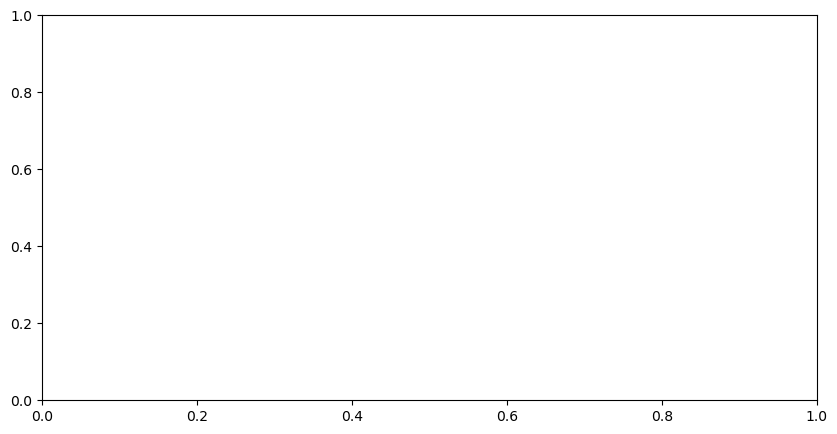

In [8]:
# Plot sky localisation area vs tier
fig, ax = plt.subplots(figsize=(10, 5))
for idx, snr in enumerate(snrs):
    rows = sorted(by_snr[snr], key=lambda r: tiers.index(r["tier"]))
    areas = [r["area90_deg2"] for r in rows]
    ax.plot(tiers, areas, marker="o", label=f"SNR {snr}")
ax.set_xticklabels(tiers, rotation=45, ha="right")
ax.set_ylabel("90% area [deg^2]")
ax.set_title("Sky localisation area vs distance prior tier")
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Visualise posterior sky maps for all SNR and tier combinations

# Get injected positions for each SNR from the likelihood cache
injected_positions = {}
for snr in snrs:
    cached_data = likelihood_cache._cache.get(snr)
    if cached_data:
        inj_cos = cached_data["data"]["cw_draws"][0]["cos_gwtheta"]
        inj_phi = cached_data["data"]["cw_draws"][0]["gwphi"]
        injected_positions[snr] = (inj_cos, inj_phi)

# Create one figure per tier, with 3 subplots (one per SNR)
for tier in tiers:
    fig, axes = plt.subplots(1, len(snrs), figsize=(6 * len(snrs), 5))
    
    # Handle single SNR case
    if len(snrs) == 1:
        axes = [axes]
    
    for i, snr in enumerate(snrs):
        ax = axes[i]
        key = (snr, tier)
        
        # Check if this combination exists in posterior_cache
        if key not in posterior_cache:
            ax.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f"SNR={snr}", fontsize=11)
            ax.axis('off')
            continue
        
        post = posterior_cache[key]
        cos_grid = post["cos_grid"]
        phi_grid = post["phi_grid"]
        posterior = post["posterior"]
        
        # Get injected position for zooming
        if snr in injected_positions:
            inj_cos, inj_phi = injected_positions[snr]
            inj_phi_wrap = (inj_phi + 2 * np.pi) % (2 * np.pi)
            
            # Compute zoom region (±0.3 radians around injection)
            zoom_margin = 0.3
            cos_min = max(cos_grid.min(), inj_cos - zoom_margin)
            cos_max = min(cos_grid.max(), inj_cos + zoom_margin)
            phi_min = max(phi_grid.min(), inj_phi_wrap - zoom_margin)
            phi_max = min(phi_grid.max(), inj_phi_wrap + zoom_margin)
        else:
            # Use full grid if no injection position
            cos_min, cos_max = cos_grid.min(), cos_grid.max()
            phi_min, phi_max = phi_grid.min(), phi_grid.max()
        
        # Plot posterior heatmap directly (no interpolation)
        pcm = ax.pcolormesh(phi_grid, cos_grid, posterior, shading="auto", cmap='viridis')
        
        # Compute and plot 30%, 60%, 90% credible region contours
        for frac, color, linestyle, linewidth in [(0.3, 'cyan', '-', 1.5), 
                                                    (0.6, 'yellow', '-', 1.5), 
                                                    (0.9, 'white', '--', 2)]:
            flat = posterior.ravel()
            order = np.argsort(flat)[::-1]
            csum = np.cumsum(flat[order])
            mask_frac = csum <= frac
            if not mask_frac.any():
                mask_frac[0] = True
            selected = np.zeros_like(flat, dtype=bool)
            selected[order[mask_frac]] = True
            mask_contour = selected.reshape(posterior.shape)
            
            ax.contour(phi_grid, cos_grid, mask_contour.astype(float), levels=[0.5],
                      colors=[color], linestyles=[linestyle], linewidths=linewidth,
                      label=f'{int(frac*100)}% CR')
        
        # Mark injected position
        if snr in injected_positions:
            inj_cos, inj_phi = injected_positions[snr]
            inj_phi_wrap = (inj_phi + 2 * np.pi) % (2 * np.pi)
            ax.plot(inj_phi_wrap, inj_cos, 'r*', markersize=15,
                   markeredgecolor='white', markeredgewidth=1, label='Injected', zorder=10)
        
        # Set zoom limits
        ax.set_xlim(phi_min, phi_max)
        ax.set_ylim(cos_min, cos_max)
        
        # Get inside90 status from results
        inside90 = None
        for res in results:
            if res["snr"] == snr and res["tier"] == tier:
                inside90 = res["inside90"]
                break
        
        # Set title with inside90 status
        status = "✓" if inside90 else "✗" if inside90 is not None else "?"
        title_color = 'green' if inside90 else 'red' if inside90 is not None else 'black'
        ax.set_title(f"SNR={snr} [{status}]", fontsize=11, color=title_color, fontweight='bold')
        
        # Labels
        ax.set_xlabel("φ (rad)", fontsize=10)
        if i == 0:
            ax.set_ylabel("cos(θ)", fontsize=10)
        
        ax.tick_params(labelsize=9)
        ax.grid(alpha=0.2, linestyle=':', linewidth=0.5)
        
        # Add colorbar
        cbar = plt.colorbar(pcm, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Posterior probability', fontsize=9)
        cbar.ax.tick_params(labelsize=8)
        
        # Add legend for first subplot
        if i == 0:
            ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
    
    plt.suptitle(f"Sky Localization: {tier}\n"
                 f"Contours: 30% (cyan), 60% (yellow), 90% (white dashed) | "
                 f"Red star = injected position | [✓/✗] = inside/outside 90% CR",
                 fontsize=13, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

## Sanity tests: prior width & D vs tier (toy PTA)

A 1-pulsar PTA check to verify that distance prior width (σ) affects the marginalised CW likelihood and the detection statistic. Because distances are analytically marginalised, the dependence enters via the coherence factor κ; we vary σ (loose vs tight priors) and inspect the log posterior and D.

FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cann

W1204 01:38:21.362543  749546 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W1204 01:38:21.363435  749042 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.


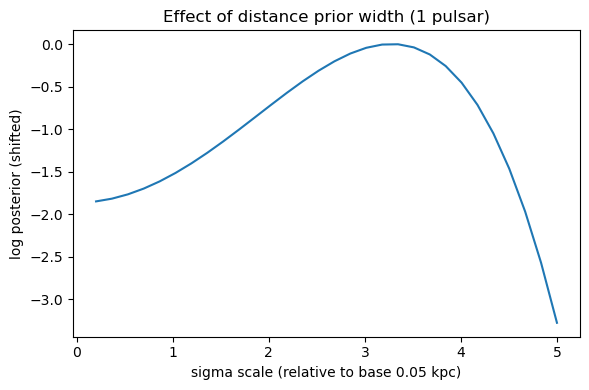

Toy PTA detection statistic by tier (manual sigma):
  real  : sigma=0.0020 kpc, D=293753893.693 (logpost max -939331.186, null -147816278.032)
  tier1 : sigma=0.0100 kpc, D=293706202.943 (logpost max -963176.561, null -147816278.032)
  tier2 : sigma=0.0010 kpc, D=293760274.818 (logpost max -936140.623, null -147816278.032)
  tier3 : sigma=0.0000 kpc, D=293762382.290 (logpost max -935086.887, null -147816278.032)


In [ ]:
# Toy PTA sanity checks (1 pulsar) with explicit sigma control
from optimization_helpers import load_discovery_pulsars_cached

toy_cfg = Q1Config(
    n_pulsars=1,
    scenario=scenario,
    seed=999,
    distance_tier=DistanceTier("real", 1.0),
    include_pterm=True,
    same_freq=False,
    same_loc=False,
)

toy_data = simulate_data(10, toy_cfg)
psr_names = list(toy_data["true_dists"].keys())
cos_grid_toy = np.linspace(-1, 1, 20)
phi_grid_toy = np.linspace(0, 2*np.pi, 20)
amp_grid_toy = np.linspace(-13.5, -11.0, 8)

pname = f"{psr_names[0]}_cw_p_dist"
d_true = toy_data["true_dists"][psr_names[0]]
base_sigma = 0.002  # kpc baseline for toy so κ is neither 0 nor 1

# Log posterior as a function of sigma scaling
scales = np.linspace(0.2, 5.0, 30)
logposts = []
for scale in scales:
    sig = base_sigma * scale
    priors = {psr_names[0]: (d_true, sig)}
    d_psrs = load_discovery_pulsars_cached(toy_cfg)
    logl_toy, param_keys_toy = build_discovery_loglike_marginalized(
        d_psrs,
        toy_data["cw_draws"],
        toy_cfg,
        priors,
        ring_vecs=toy_data["ring_vecs"],
        residual_map=toy_data["residual_map"],
        include_cw=True,
    )
    base_params_toy = build_base_params(param_keys_toy, toy_data["inj_params"], toy_data["cw_draws"])
    logposts.append(float(logl_toy(base_params_toy)))
logposts = np.array(logposts)
plt.figure(figsize=(6,4))
plt.plot(scales, logposts - logposts.max())
plt.xlabel(r"sigma scale (relative to base 0.05 kpc)")
plt.ylabel("log posterior (shifted)")
plt.title("Effect of distance prior width (1 pulsar)")
plt.tight_layout()
plt.show()

# Detection statistic vs manually defined tiers (controlled sigma)
print("Toy PTA detection statistic by tier (manual sigma):")
tier_sigmas = {
    "real": base_sigma,
    "tier1": base_sigma * 5.0,
    "tier2": base_sigma / 2.0,
    "tier3": 1e-6,
}
for tier, sig in tier_sigmas.items():
    priors = {psr_names[0]: (d_true, sig)}
    d_psrs = load_discovery_pulsars(toy_cfg)
    logl_toy, param_keys_toy = build_discovery_loglike_marginalized(
        d_psrs,
        toy_data["cw_draws"],
        toy_cfg,
        priors,
        ring_vecs=toy_data["ring_vecs"],
        residual_map=toy_data["residual_map"],
        include_cw=True,
    )
    base_params_toy = build_base_params(param_keys_toy, toy_data["inj_params"], toy_data["cw_draws"])
    cw_names_toy = find_cw_param_names(param_keys_toy)
    d_stat, logL_null, logL_max, _ = compute_detection_statistic(
        logl_toy,
        param_keys_toy,
        base_params_toy,
        cw_names_toy,
        cos_grid_toy,
        phi_grid_toy,
        amp_grid_toy,
        null_amp=null_amp,
    )
    print(f"  {tier:6s}: sigma={sig:.4f} kpc, D={d_stat:.3f} (logpost max {logL_max:.3f}, null {logL_null:.3f})")


## Diagnostics: κ distribution for current tiers
Compute kσ and κ for a small PTA to check if tiers differ (κ in (0,1)).

In [ ]:
# Compute kσ and κ for tiers on a small PTA
cfg_diag = cfg.replace(n_pulsars=5) if hasattr(cfg, 'replace') else Q1Config(n_pulsars=5, scenario=scenario, seed=seed, distance_tier=DistanceTier("real",1.0), include_pterm=True)
data_diag = simulate_data(snrs[0], cfg_diag)
psr_names_diag = list(data_diag["true_dists"].keys())

for tier in tiers:
    dist_priors = apply_distance_prior_tier(psr_names_diag, data_diag["true_dists"], data_diag["true_sigs"], tier)
    ks = []
    kappas = []
    for psr in psr_names_diag:
        mu, sig = dist_priors[psr]
        # approximate average (1+cos_mu) ~1 for rough diagnostic
        f = 10 ** (log10_fgw_override if log10_fgw_override is not None else -9.5)
        ksig = 2 * np.pi * f * sig * (3.085677581491367e19) / 299792458.0  # ksig ~ 2pi f sigma_d * kpc/c with (1+cos_mu)~1
        ks.append(ksig)
        kappas.append(np.exp(-0.5 * ksig**2))
    print(f"Tier {tier}: kσ median={np.median(ks):.2e}, κ median={np.median(kappas):.2e}, range κ=({np.min(kappas):.2e},{np.max(kappas):.2e})")


FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cann

## Diagnostics: posterior variation per tier/SNR
Check dispersion of logL_grid and posterior to see if sky posteriors are flat (causing constant area).

In [ ]:
# Report logL_grid std and posterior spread for each cached run
for key, post in posterior_cache.items():
    lg = post["logL_grid"]
    std = np.std(lg)
    pt = post["posterior"]
    pstd = np.std(pt)
    print(f"{key}: logL std={std:.3e}, posterior std={pstd:.3e}")


NameError: name 'posterior_cache' is not defined

In [ ]:
# Save all plots and data for reproducibility
import pickle
from datetime import datetime

# Create output directory
output_dir = Path("/home/mattm/projects/HSYMT/MAIN_PROJECT_QUESTIONS/Q1/results")
output_dir.mkdir(exist_ok=True)

# Create timestamp for this run
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_dir = output_dir / f"run_{timestamp}"
run_dir.mkdir(exist_ok=True)

print(f"Saving results to: {run_dir}")

# 1. Save configuration and metadata
metadata = {
    "timestamp": timestamp,
    "scenario": scenario,
    "n_pulsars": n_pulsars,
    "seed": seed,
    "snrs": snrs,
    "tiers": tiers,
    "n_cos": n_cos,
    "n_phi": n_phi,
    "n_amp": n_amp,
    "amp_span": amp_span,
    "log10_fgw_override": log10_fgw_override,
}
with open(run_dir / "metadata.pkl", "wb") as f:
    pickle.dump(metadata, f)
print("✓ Saved metadata")

# 2. Save results data
with open(run_dir / "results.pkl", "wb") as f:
    pickle.dump(results, f)
print(f"✓ Saved results ({len(results)} entries)")

# 3. Save posterior cache
with open(run_dir / "posterior_cache.pkl", "wb") as f:
    pickle.dump(posterior_cache, f)
print(f"✓ Saved posterior_cache ({len(posterior_cache)} entries)")

# 4. Save injected positions
injected_positions = {}
for snr in snrs:
    cached_data = likelihood_cache._cache.get(snr)
    if cached_data:
        inj_cos = cached_data["data"]["cw_draws"][0]["cos_gwtheta"]
        inj_phi = cached_data["data"]["cw_draws"][0]["gwphi"]
        injected_positions[snr] = (inj_cos, inj_phi)
with open(run_dir / "injected_positions.pkl", "wb") as f:
    pickle.dump(injected_positions, f)
print(f"✓ Saved injected_positions")

# 5. Save ensemble_D data (if it exists)
if 'ensemble_D' in globals():
    with open(run_dir / "ensemble_D.pkl", "wb") as f:
        pickle.dump(ensemble_D, f)
    print(f"✓ Saved ensemble_D")

# 6. Generate and save detection statistic plots
print("\nGenerating detection statistic plots...")

# Plot 1: Combined view
fig, ax = plt.subplots(figsize=(10, 5))
x_positions = np.arange(len(tiers))
width = 0.25
for idx, snr in enumerate(snrs):
    rows = sorted(by_snr[snr], key=lambda r: tiers.index(r["tier"]))
    vals = [r["D_stat"] for r in rows]
    ax.bar(x_positions + idx * width, vals, width=width, label=f"SNR {snr}")
ax.set_xticks(x_positions + width * (len(snrs) - 1) / 2)
ax.set_xticklabels(tiers, rotation=45, ha="right")
ax.set_ylabel("Detection statistic D")
ax.set_yscale('log')
ax.legend()
ax.set_title("Detection statistic vs distance prior tier (marginalised CW)")
plt.tight_layout()
fig.savefig(run_dir / "dstat_combined.png", dpi=300, bbox_inches='tight')
fig.savefig(run_dir / "dstat_combined.pdf", bbox_inches='tight')
plt.close(fig)
print("  ✓ dstat_combined")

# Plot 2: Individual per SNR
fig, axes = plt.subplots(1, len(snrs), figsize=(5 * len(snrs), 4), sharey=False)
if len(snrs) == 1:
    axes = [axes]
for idx, snr in enumerate(snrs):
    ax = axes[idx]
    rows = sorted(by_snr[snr], key=lambda r: tiers.index(r["tier"]))
    vals = [r["D_stat"] for r in rows]
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(tiers)))
    ax.bar(range(len(tiers)), vals, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(tiers)))
    ax.set_xticklabels(tiers, rotation=45, ha="right")
    ax.set_xlabel("Distance prior tier")
    ax.set_ylabel("Detection statistic D")
    ax.set_title(f"SNR = {snr}")
    ax.set_yscale('log')
    ax.grid(axis='y', alpha=0.3, which='both')
plt.suptitle("Detection Statistic by Distance Prior Tier (per SNR, log scale)", y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(run_dir / "dstat_per_snr.png", dpi=300, bbox_inches='tight')
fig.savefig(run_dir / "dstat_per_snr.pdf", bbox_inches='tight')
plt.close(fig)
print("  ✓ dstat_per_snr")

# Plot 3: Stacked line plots
fig, axes = plt.subplots(len(snrs), 1, figsize=(10, 4 * len(snrs)), sharex=True)
if len(snrs) == 1:
    axes = [axes]
for idx, snr in enumerate(snrs):
    ax = axes[idx]
    rows = sorted(by_snr[snr], key=lambda r: tiers.index(r["tier"]))
    vals = [r["D_stat"] for r in rows]
    ax.plot(range(len(tiers)), vals, marker='o', linewidth=2, markersize=8, 
            color=f'C{idx}', label=f"SNR {snr}")
    ax.set_ylabel("Detection statistic D")
    ax.set_yscale('log')
    ax.legend(loc='best')
    ax.grid(alpha=0.3, which='both')
axes[-1].set_xticks(range(len(tiers)))
axes[-1].set_xticklabels(tiers, rotation=45, ha="right")
axes[-1].set_xlabel("Distance prior tier")
plt.suptitle("Detection Statistic Trends Across Distance Prior Tiers (log scale)", y=0.995, fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(run_dir / "dstat_trends.png", dpi=300, bbox_inches='tight')
fig.savefig(run_dir / "dstat_trends.pdf", bbox_inches='tight')
plt.close(fig)
print("  ✓ dstat_trends")

# Plot 4: Without tier1 (stacked)
tiers_no_tier1 = [t for t in tiers if t != "tier1"]
fig, axes = plt.subplots(len(snrs), 1, figsize=(10, 4 * len(snrs)), sharex=True)
if len(snrs) == 1:
    axes = [axes]
for idx, snr in enumerate(snrs):
    ax = axes[idx]
    rows = sorted(by_snr[snr], key=lambda r: tiers.index(r["tier"]))
    rows_filtered = [r for r in rows if r["tier"] != "tier1"]
    vals = [r["D_stat"] for r in rows_filtered]
    ax.plot(range(len(vals)), vals, marker='o', linewidth=2, markersize=8, 
            color=f'C{idx}', label=f"SNR {snr}")
    ax.set_ylabel("Detection statistic D")
    ax.set_yscale('log')
    ax.legend(loc='best')
    ax.grid(alpha=0.3, which='both')
axes[-1].set_xticks(range(len(tiers_no_tier1)))
axes[-1].set_xticklabels(tiers_no_tier1, rotation=45, ha="right")
axes[-1].set_xlabel("Distance prior tier")
plt.suptitle("Detection Statistic Trends (excluding tier1)", y=0.995, fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(run_dir / "dstat_trends_no_tier1.png", dpi=300, bbox_inches='tight')
fig.savefig(run_dir / "dstat_trends_no_tier1.pdf", bbox_inches='tight')
plt.close(fig)
print("  ✓ dstat_trends_no_tier1")

# Plot 5: Individual per SNR without tier1
fig, axes = plt.subplots(1, len(snrs), figsize=(5 * len(snrs), 4), sharey=False)
if len(snrs) == 1:
    axes = [axes]
for idx, snr in enumerate(snrs):
    ax = axes[idx]
    rows = sorted(by_snr[snr], key=lambda r: tiers.index(r["tier"]))
    rows_filtered = [r for r in rows if r["tier"] != "tier1"]
    vals = [r["D_stat"] for r in rows_filtered]
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(vals)))
    ax.bar(range(len(vals)), vals, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(tiers_no_tier1, rotation=45, ha="right")
    ax.set_xlabel("Distance prior tier")
    ax.set_ylabel("Detection statistic D")
    ax.set_title(f"SNR = {snr}")
    ax.set_yscale('log')
    ax.grid(axis='y', alpha=0.3, which='both')
plt.suptitle("Detection Statistic by Distance Prior Tier (per SNR, excluding tier1)", y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(run_dir / "dstat_per_snr_no_tier1.png", dpi=300, bbox_inches='tight')
fig.savefig(run_dir / "dstat_per_snr_no_tier1.pdf", bbox_inches='tight')
plt.close(fig)
print("  ✓ dstat_per_snr_no_tier1")

# 7. Save sky localization area plot
print("\nGenerating sky localization area plot...")
fig, ax = plt.subplots(figsize=(10, 5))
for idx, snr in enumerate(snrs):
    rows = sorted(by_snr[snr], key=lambda r: tiers.index(r["tier"]))
    areas = [r["area90_deg2"] for r in rows]
    ax.plot(tiers, areas, marker="o", label=f"SNR {snr}")
ax.set_xticklabels(tiers, rotation=45, ha="right")
ax.set_ylabel("90% area [deg^2]")
ax.set_title("Sky localisation area vs distance prior tier")
ax.legend()
plt.tight_layout()
fig.savefig(run_dir / "sky_area_vs_tier.png", dpi=300, bbox_inches='tight')
fig.savefig(run_dir / "sky_area_vs_tier.pdf", bbox_inches='tight')
plt.close(fig)
print("  ✓ sky_area_vs_tier")

# 8. Save posterior sky maps (one per tier)
print("\nGenerating posterior sky maps...")
sky_maps_dir = run_dir / "sky_maps"
sky_maps_dir.mkdir(exist_ok=True)

for tier in tiers:
    fig, axes = plt.subplots(1, len(snrs), figsize=(6 * len(snrs), 5))
    if len(snrs) == 1:
        axes = [axes]
    
    for i, snr in enumerate(snrs):
        ax = axes[i]
        key = (snr, tier)
        
        if key not in posterior_cache:
            ax.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f"SNR={snr}", fontsize=11)
            ax.axis('off')
            continue
        
        post = posterior_cache[key]
        cos_grid = post["cos_grid"]
        phi_grid = post["phi_grid"]
        posterior = post["posterior"]
        
        # Get injected position for zooming
        if snr in injected_positions:
            inj_cos, inj_phi = injected_positions[snr]
            inj_phi_wrap = (inj_phi + 2 * np.pi) % (2 * np.pi)
            zoom_margin = 0.3
            cos_min = max(cos_grid.min(), inj_cos - zoom_margin)
            cos_max = min(cos_grid.max(), inj_cos + zoom_margin)
            phi_min = max(phi_grid.min(), inj_phi_wrap - zoom_margin)
            phi_max = min(phi_grid.max(), inj_phi_wrap + zoom_margin)
        else:
            cos_min, cos_max = cos_grid.min(), cos_grid.max()
            phi_min, phi_max = phi_grid.min(), phi_grid.max()
        
        pcm = ax.pcolormesh(phi_grid, cos_grid, posterior, shading="auto", cmap='viridis')
        
        # Contours
        for frac, color, linestyle, linewidth in [(0.3, 'cyan', '-', 1.5), 
                                                    (0.6, 'yellow', '-', 1.5), 
                                                    (0.9, 'white', '--', 2)]:
            flat = posterior.ravel()
            order = np.argsort(flat)[::-1]
            csum = np.cumsum(flat[order])
            mask_frac = csum <= frac
            if not mask_frac.any():
                mask_frac[0] = True
            selected = np.zeros_like(flat, dtype=bool)
            selected[order[mask_frac]] = True
            mask_contour = selected.reshape(posterior.shape)
            ax.contour(phi_grid, cos_grid, mask_contour.astype(float), levels=[0.5],
                      colors=[color], linestyles=[linestyle], linewidths=linewidth,
                      label=f'{int(frac*100)}% CR')
        
        # Injected position
        if snr in injected_positions:
            inj_cos, inj_phi = injected_positions[snr]
            inj_phi_wrap = (inj_phi + 2 * np.pi) % (2 * np.pi)
            ax.plot(inj_phi_wrap, inj_cos, 'r*', markersize=15,
                   markeredgecolor='white', markeredgewidth=1, label='Injected', zorder=10)
        
        ax.set_xlim(phi_min, phi_max)
        ax.set_ylim(cos_min, cos_max)
        
        # inside90 status
        inside90 = None
        for res in results:
            if res["snr"] == snr and res["tier"] == tier:
                inside90 = res["inside90"]
                break
        
        status = "✓" if inside90 else "✗" if inside90 is not None else "?"
        title_color = 'green' if inside90 else 'red' if inside90 is not None else 'black'
        ax.set_title(f"SNR={snr} [{status}]", fontsize=11, color=title_color, fontweight='bold')
        
        ax.set_xlabel("φ (rad)", fontsize=10)
        if i == 0:
            ax.set_ylabel("cos(θ)", fontsize=10)
        ax.tick_params(labelsize=9)
        ax.grid(alpha=0.2, linestyle=':', linewidth=0.5)
        
        cbar = plt.colorbar(pcm, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Posterior probability', fontsize=9)
        cbar.ax.tick_params(labelsize=8)
        
        if i == 0:
            ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
    
    plt.suptitle(f"Sky Localization: {tier}\n"
                 f"Contours: 30% (cyan), 60% (yellow), 90% (white dashed) | "
                 f"Red star = injected position | [✓/✗] = inside/outside 90% CR",
                 fontsize=13, fontweight='bold', y=1.00)
    plt.tight_layout()
    
    # Clean tier name for filename
    tier_clean = tier.replace("=", "_").replace(".", "p")
    fig.savefig(sky_maps_dir / f"skymap_{tier_clean}.png", dpi=300, bbox_inches='tight')
    fig.savefig(sky_maps_dir / f"skymap_{tier_clean}.pdf", bbox_inches='tight')
    plt.close(fig)
    print(f"  ✓ skymap_{tier_clean}")

print(f"\n{'='*60}")
print(f"All plots and data saved to:")
print(f"  {run_dir}")
print(f"{'='*60}")